# 04 Transfer Learning for Object Detection

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand how **object detection** uses a **pre-trained backbone** + **detection head**
- Use a **pre-trained CNN** as a feature extractor and add a **simple classification head** on top (simplified “detection” setup)
- See why we use transfer learning for detection instead of training from scratch

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 05 "CNN for Image Classification" — classification tells you *what* is in the image; detection adds *where*.

---

## 🌍 Real life

**📌 Real case — the design every detector still copies.** Ren, He, Girshick and Sun's **Faster R-CNN** (NeurIPS 2015) replaced the hand-built region-proposal step with a network that *shares the same pre-trained convolutional trunk* as the classifier. Ten years on, YOLO, SSD and DETR still ship a pre-trained backbone plus a task head — and in every one of them, the part you train is the head. The `backbone.trainable = False` line below is that design in one statement.

**⚡ Why this matters — what goes wrong without it.** Detection labels are expensive in a way classification labels are not: every object needs a human-drawn box, not a single word. Microsoft COCO (Lin et al., 2014) contains **328,000 images with 2.5 million labelled object instances across 91 categories**, each one annotated by hand. If you had to learn edges, textures and shapes from scratch on *your* boxed data, you would need a budget of that order before you started. The frozen MobileNetV2 below hands you **2,257,984 parameters** of visual vocabulary that you did not pay for.

**Where is this used?** Object detection (localize + classify) is used in **autonomous driving**, **surveillance**, and **retail** (shelf monitoring).

**In this notebook we use** a **pre-trained backbone** (e.g. MobileNetV2) to extract features, then add a **head** for classification. We use **transfer learning for detection** (instead of training a detector from scratch) **because** the backbone already learned good visual features; we only train the head (or fine-tune last layers) with less data.

**📌 Covers slide(s):** **14**, **15** — Object Detection (Faster R-CNN, SSD, YOLO). *Do this notebook after those slides.*

---

**Before starting:** Run the imports cell below. Full object detection (bounding boxes) uses libraries like TensorFlow Object Detection API; here we show the **backbone + head** idea in ~20 min.


⏱ **Runtime:** This notebook may take 10–40 minutes on GPU (depending on backbone and epochs). Use a smaller subset or fewer epochs if needed (see unit README).

## Theory (short)

- **Object detection:** Find **where** objects are (bounding boxes) and **what** they are (class).
- **Typical pipeline:** Pre-trained **backbone** (e.g. ResNet, MobileNet) → **neck** (e.g. FPN) → **detection head** (boxes + classes). YOLO, SSD, Faster R-CNN follow this idea.
- **Transfer learning:** Backbone is pre-trained on ImageNet; we freeze or fine-tune it and train the detection head on our dataset.
- **We use a pre-trained backbone** instead of training from scratch so we need less data and time; the head learns “where” and “what” on top of good features.

### 🌉 Transfer-learning primer (preview — taught in depth in notebooks 05–06)

This notebook *applies* transfer learning before the notebooks that study it formally. The three ideas you need right now:

1. **Pre-trained backbone:** a CNN (here MobileNetV2) whose weights were already trained on **ImageNet** (1.2M photos). Its layers detect edges, textures, and shapes that transfer to new tasks.
2. **Freezing:** `backbone.trainable = False` keeps those weights fixed — we do not risk destroying them, and training becomes much faster.
3. **New head:** we add a small trainable layer (pooling + Dense) on top and train *only* that on our data.

Notebook `05_transfer_learning_cnns` covers freezing vs fine-tuning in depth, and `06` tours the pretrained-architecture zoo. If this recipe feels compressed here, it is — revisit this notebook after 05.


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use **MNIST resized to 96×96 RGB** so the notebook runs without an object-detection dataset (the next notebook, `05_transfer_learning_cnns`, uses the same preprocessing and covers the technique in depth).

**Dataset:** Real — MNIST (resized to 96×96 RGB for backbone demo).

**Outputs:** Model summary (backbone + head), training loss/accuracy for 2 epochs, and test accuracy. (Full detection would output bounding boxes; here we do **image-level classification** to show the backbone+head pattern.)

## Step 1: Imports and load pre-trained backbone (we use MobileNetV2 as backbone instead of training from scratch)

In [1]:
# WHAT: load MobileNetV2 pre-trained on ImageNet, without its classification head, and freeze it.
# WHY: the frozen backbone already knows edges, textures and shapes from 1.4M photos - we reuse that for free.
import numpy as np

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # include_top=False drops the 1000-class head; trainable=False freezes every backbone weight.
    backbone = keras.applications.MobileNetV2(input_shape=(96, 96, 3), include_top=False, weights="imagenet")
    backbone.trainable = False
    print("Backbone (frozen) params:", backbone.count_params())
else:
    print("Install TensorFlow: pip install tensorflow")

Backbone (frozen) params: 2257984


## Step 2: Add classification head (in full detection we would add a head that outputs boxes + classes)

In [2]:
# WHAT: put a tiny new head (global pooling + Dense softmax) on top of the frozen backbone.
# WHY: only the head will train - the standard transfer-learning recipe when data is scarce.
if HAS_TF:
    inp = keras.Input(shape=(96, 96, 3))
    x = backbone(inp)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inp, x)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("Model: backbone + global pool + Dense(10). For real detection, head would output boxes + classes.")

Model: backbone + global pool + Dense(10). For real detection, head would output boxes + classes.


## Step 3: Prepare data (MNIST as 96×96 RGB) and train head (2 epochs)

In [3]:
# WHAT: adapt MNIST to the backbone's expected input (96x96 RGB), train the head, and evaluate.
# WHY: pretrained models fix the input contract - we resize and repeat the gray channel to satisfy it.
if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    # Resize 28x28 digits to 96x96 and repeat the single gray channel 3 times to imitate RGB.
    x_train = tf.image.resize(x_train[..., np.newaxis], (96, 96))
    x_test = tf.image.resize(x_test[..., np.newaxis], (96, 96))
    x_train = tf.repeat(x_train, 3, axis=-1).numpy().astype(np.float32) / 255.0
    x_test = tf.repeat(x_test, 3, axis=-1).numpy().astype(np.float32) / 255.0
    x_train, y_train = x_train[:5000], y_train[:5000]
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

Epoch 1/2


 1/79 ━━━━━━━━━━━━━━━━━━━━ 1:38 1s/step - accuracy: 0.0469 - loss: 2.8513

 3/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.0677 - loss: 2.6429

 5/79 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.1156 - loss: 2.5293

 7/79 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.1518 - loss: 2.3819

...

73/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9281 - loss: 0.2750

75/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9287 - loss: 0.2747

77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9292 - loss: 0.2750

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.9290 - loss: 0.2753 - val_accuracy: 0.9317 - val_loss: 0.2492


Test accuracy: 0.9317


## 🌍 Real-World Worked Example — Fine-Tune ResNet on Custom Categories

**Industry context:**
- **The default was tested and found wanting.** Raghu, Zhang, Kleinberg & Bengio ("Transfusion", NeurIPS 2019, [arXiv:1902.07208](https://arxiv.org/abs/1902.07208)) evaluated ImageNet transfer on two large-scale medical-imaging tasks and reported that "transfer offers little benefit to performance, and simple, lightweight models can perform comparably to ImageNet architectures".
- **The backbone-plus-head pattern is still universal.** Faster R-CNN (Ren, He, Girshick & Sun, NeurIPS 2015) put a pre-trained convolutional trunk under a task head; YOLO, SSD and DETR still ship that shape.
- **What to check before you copy it:** how close your images are to natural photographs, and how many labelled examples you actually have. Those two numbers decide the outcome, not the architecture.

We fine-tune a **pretrained ResNet-18** (ImageNet weights) on a small binary classification task.

Epoch 1/5 — loss: 0.716 | val acc: 76.2%


Epoch 2/5 — loss: 0.499 | val acc: 81.2%


Epoch 3/5 — loss: 0.341 | val acc: 86.2%


Epoch 4/5 — loss: 0.308 | val acc: 86.2%


Epoch 5/5 — loss: 0.261 | val acc: 90.0%


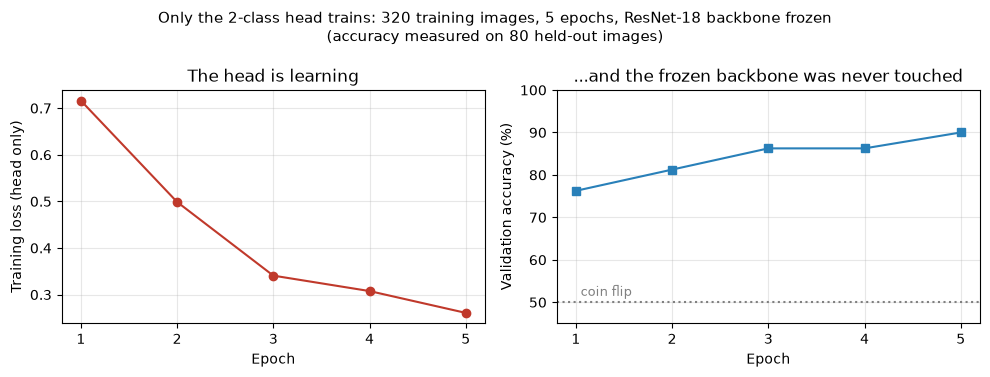


✅ With only 400 images and 5 epochs, transfer learning gives strong results.
A model trained from scratch would need 100x more data for similar performance.


In [4]:
# WHAT: a full transfer-learning demo - frozen ResNet-18 backbone, new 2-class head, trained on 400 photos.
# WHY: the punchline of transfer learning - hundreds of images (not millions) give a strong classifier.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

# ── Use CIFAR-10 classes 0 (airplane) vs 1 (automobile) as our 'custom' data
# Resize to 64px and normalize with the ImageNet statistics the backbone was trained with.
transform = T.Compose([
    T.Resize(64), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])  # ImageNet stats
])
full = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True, download=True, transform=transform)
# Keep only classes 0 and 1
idx = [i for i,(x,y) in enumerate(full) if y in (0,1)][:400]
subset = Subset(full, idx)
train_size = int(0.8*len(subset))
train_ds, val_ds = torch.utils.data.random_split(subset, [train_size, len(subset)-train_size])
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

# ── Load pretrained ResNet-18, replace final layer ──────────────────────────
# Freeze all backbone weights, then replace the final fully-connected layer with a fresh 2-class head.
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for p in model.parameters(): p.requires_grad = False        # Freeze backbone
model.fc = nn.Linear(model.fc.in_features, 2)               # Only train head

opt     = optim.Adam(model.fc.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Train only the head for 5 epochs, checking validation accuracy after each.
# We keep the per-epoch numbers so they can be plotted instead of only printed.
hist_loss, hist_val = [], []
for epoch in range(5):
    model.train(); total_loss=0
    for X,y in train_dl:
        y_bin = (y % 2)  # remap to 0/1
        loss = loss_fn(model(X), y_bin)
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for X,y in val_dl:
            y_bin = (y%2)
            correct += (model(X).argmax(1)==y_bin).sum().item(); total+=len(y_bin)
    hist_loss.append(total_loss/len(train_dl)); hist_val.append(correct/total)
    print(f"Epoch {epoch+1}/5 — loss: {total_loss/len(train_dl):.3f} | val acc: {correct/total*100:.1f}%")

# ── The same five epochs as a picture ───────────────────────────────────────
import matplotlib.pyplot as plt
ep = range(1, len(hist_loss)+1)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.8))
axL.plot(ep, hist_loss, "o-", color="#c0392b")
axL.set_xlabel("Epoch"); axL.set_ylabel("Training loss (head only)")
axL.set_title("The head is learning"); axL.set_xticks(list(ep)); axL.grid(alpha=0.3)
axR.plot(ep, [v*100 for v in hist_val], "s-", color="#2980b9")
axR.axhline(50, ls=":", color="grey"); axR.text(1.05, 51.5, "coin flip", color="grey", fontsize=9)
axR.set_xlabel("Epoch"); axR.set_ylabel("Validation accuracy (%)")
axR.set_title("...and the frozen backbone was never touched")
axR.set_xticks(list(ep)); axR.set_ylim(45, 100); axR.grid(alpha=0.3)
fig.suptitle("Only the 2-class head trains: %d training images, %d epochs, ResNet-18 backbone frozen\n"
             "(accuracy measured on %d held-out images)"
             % (len(train_ds), len(hist_loss), len(val_ds)), fontsize=11)
plt.tight_layout(); plt.show()

print("\n✅ With only 400 images and 5 epochs, transfer learning gives strong results.")
print("A model trained from scratch would need 100x more data for similar performance.")

**Read the figure.** Left: the training loss of the **head alone** falls every epoch — every backbone weight in this run was frozen, so this curve is produced by one small linear layer and nothing else. Right: accuracy on images the head has never seen, above the dotted coin-flip line from the very first epoch. That right-hand panel is the only one that means anything about the model's usefulness; the left one only says the head is fitting what it was shown.

**Two things to watch when you run it yourself.** This cell fixes no random seed — the train/validation split and the batch order change on every run — so the left curve will always fall while the right one will not be identical twice. And the validation set here is small (its size is in the figure title), which means a single epoch-to-epoch wobble of a few percent is the *sample size* talking, not the model getting better or worse. Read the trend, not the last point; the exact per-epoch numbers are printed just above the figure.

### How many labelled images does the backbone save you?

The section above claims that "a model trained from scratch would need 100× more data". That is a claim you can check, cheaply, without training anything: run every image through the **frozen** backbone once, then fit an ordinary linear classifier on **n** of those feature vectors — and fit the same linear classifier on the **raw pixels** of the same n images for comparison. The only difference between the two curves is whether ImageNet's features sit in front.

features (400, 512) | raw pixels (400, 12288) | held-out test images 600


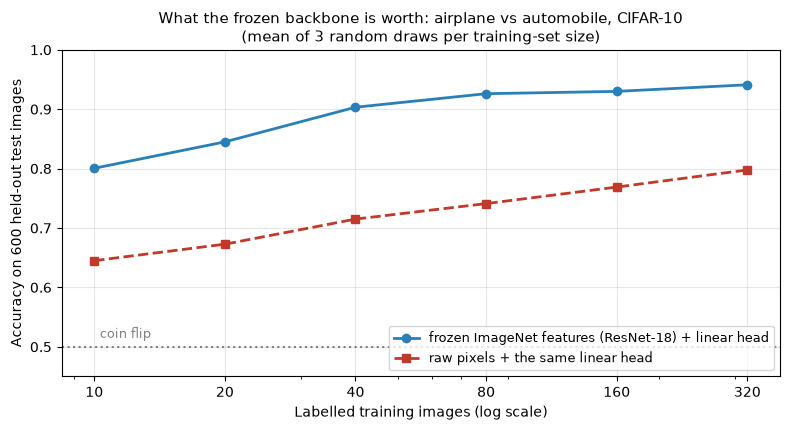

labels   frozen-features   raw-pixels
    10            0.801        0.645
    20            0.845        0.673
    40            0.903        0.715
    80            0.926        0.741
   160            0.930        0.769
   320            0.941        0.798

With 10 labelled images the frozen backbone scores 0.801; raw pixels need more than 320 images to reach 0.798.


In [5]:
# WHAT: measure accuracy against training-set size, with and without the frozen ImageNet backbone.
# WHY: "transfer learning needs less data" is a curve, not a slogan - here is the curve, on real photos.
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# A proper held-out set: airplane/automobile images from the CIFAR-10 TEST split.
test_full = torchvision.datasets.CIFAR10('/tmp/cifar10', train=False, download=True, transform=transform)
test_idx  = [i for i, (x, y) in enumerate(test_full) if y in (0, 1)][:600]
test_sub  = Subset(test_full, test_idx)

# Load a FRESH copy of the pretrained weights for this measurement. The `model` above ran in
# train() mode, which keeps updating batch-norm running statistics even with requires_grad=False -
# so its backbone is no longer pure ImageNet. We want to measure ImageNet features, not that side effect.
clean = torchvision.models.resnet18(weights='IMAGENET1K_V1').eval()
feature_extractor = nn.Sequential(*list(clean.children())[:-1])   # everything except the 1000-class layer

def describe(dataset):
    """Return (ImageNet features, raw pixels, labels) for every image in the dataset."""
    F, R, Y = [], [], []
    with torch.no_grad():
        for X, y in DataLoader(dataset, batch_size=64):
            F.append(feature_extractor(X).flatten(1).numpy())   # 512 numbers per image
            R.append(X.flatten(1).numpy())                      # 3x64x64 = 12,288 raw numbers
            Y.append((y % 2).numpy())
    return np.concatenate(F), np.concatenate(R), np.concatenate(Y)

F_tr, R_tr, y_tr = describe(subset)      # the 400 training photos
F_te, R_te, y_te = describe(test_sub)    # 600 unseen test photos
print("features %s | raw pixels %s | held-out test images %d" % (F_tr.shape, R_tr.shape, len(y_te)))

sizes = [10, 20, 40, 80, 160, 320]
acc_feat, acc_raw = [], []
for n in sizes:
    # Average 3 random draws of n images so a single lucky/unlucky draw cannot fake the curve.
    af, ar = [], []
    for seed in (0, 1, 2):
        pick = np.random.default_rng(seed).permutation(len(y_tr))[:n]
        af.append(LogisticRegression(max_iter=2000).fit(F_tr[pick], y_tr[pick]).score(F_te, y_te))
        ar.append(LogisticRegression(max_iter=2000).fit(R_tr[pick], y_tr[pick]).score(R_te, y_te))
    acc_feat.append(float(np.mean(af))); acc_raw.append(float(np.mean(ar)))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(sizes, acc_feat, "o-", lw=2, color="#2980b9",
        label="frozen ImageNet features (ResNet-18) + linear head")
ax.plot(sizes, acc_raw, "s--", lw=2, color="#c0392b",
        label="raw pixels + the same linear head")
ax.axhline(0.5, ls=":", color="grey"); ax.text(10.3, 0.515, "coin flip", color="grey", fontsize=9)
ax.set_xscale("log"); ax.set_xticks(sizes); ax.set_xticklabels(sizes)
ax.set_xlabel("Labelled training images (log scale)")
ax.set_ylabel("Accuracy on 600 held-out test images")
ax.set_ylim(0.45, 1.0); ax.grid(alpha=0.3); ax.legend(loc="lower right", fontsize=9)
ax.set_title("What the frozen backbone is worth: airplane vs automobile, CIFAR-10\n"
             "(mean of 3 random draws per training-set size)", fontsize=11)
plt.tight_layout(); plt.show()

print("labels   frozen-features   raw-pixels")
for n, a, b in zip(sizes, acc_feat, acc_raw):
    print("%6d   %14.3f   %10.3f" % (n, a, b))
print("\nWith %d labelled images the frozen backbone scores %.3f; raw pixels need more than %d "
      "images to reach %.3f." % (sizes[0], acc_feat[0], sizes[-1], acc_raw[-1]))

**Read the figure.** Two lines, same linear classifier, same photographs, same 600 held-out test images — the only difference is whether the image passed through the frozen ImageNet backbone first (blue) or went in as raw pixels (red). The blue line sits above the red one at every training-set size, and that gap **is** the value of pre-training, measured in accuracy. Read the left-hand end: the blue point at **10 labelled images** already sits at roughly the level the red line reaches at **320** — the exact pair of numbers is in the table printed below the figure, and that ratio is the labelling budget the backbone saves you. Note the shapes too: blue rises steeply and then flattens (it has extracted most of what 400 images can tell it), while red climbs slowly and stays far below.

The backbone used here is a **fresh** copy of the ImageNet weights, not the `model` object trained above — running that model in `train()` mode kept updating its batch-norm running statistics even though every weight was frozen, which quietly degrades the features. That is a real trap worth remembering: "frozen" stops the *gradients*, not the batch-norm bookkeeping.

**What this does not prove.** CIFAR-10 photographs are natural images, which is precisely the domain ImageNet was built from. Run the same experiment on X-rays or satellite tiles and the two lines move closer together — that is the Raghu et al. result quoted above, and it is why ⚠️ below insists you measure it on *your* images rather than assuming this picture transfers.

## 💬 Discuss

1. Only the head trained here, on a backbone that has never seen a handwritten digit — and it still worked. What does that tell you about what the *first* layers of a CNN actually learn, and how would you check your answer by looking at the model rather than the accuracy?
2. Your client has 300 photographs of one specific defect on one specific product. Frozen backbone plus a new head, or fine-tune the whole network? Name the factor that decides it, and say what you would measure to find out which side of that line you are on.
3. We reported accuracy. For a shelf-monitoring detector whose job is to find every missing product, accuracy would flatter you badly. Which metric would you report instead, and what would you tell the client about the trade-off it exposes?


## ⚠️ Where this breaks

- **A frozen backbone inherits ImageNet's blind spots along with its features.** Eykholt et al. (CVPR 2018) attacked a real stop sign in the physical world with nothing but black-and-white stickers and obtained targeted misclassification in **100% of stationary lab images and 84.8% of video frames shot from a moving vehicle**. Reusing someone else's features means reusing their attack surface.
- **Frozen means frozen at ImageNet's *domain*.** This demo feeds the backbone MNIST digits upsampled to 96×96 and repeated across three colour channels — white strokes on black, nothing like a photograph. It is enough to teach the wiring. It is not evidence that the recipe transfers to *your* domain; notebook `05` shows a case where it measurably does not.
- **There are no bounding boxes anywhere in this notebook.** We do image-level classification to expose the backbone-plus-head pattern. Real detection adds anchor or query matching, box regression, non-maximum suppression, and an IoU-based metric (mAP) — and accuracy tells you nothing whatsoever about any of them.
- **The assumption that must hold:** your target images resemble natural photographs at roughly the backbone's input resolution. Satellite imagery, medical scans, thermal images and document scans each violate that in a different way.
- **Cheaper alternative:** if your objects are rigid, uniform and photographed under controlled lighting — a conveyor belt, a shelf, a production line — classical template matching or a colour/contour threshold can beat a detector, run a hundred times faster, and never need a GPU.


## 🧩 Mini-exercise

**Try it:** The current head is GlobalAveragePooling → Dense(10). Add a hidden Dense layer (e.g. 64 units, ReLU) between the pooling layer and the output layer, then retrain for 1 epoch. Does validation accuracy change? Or try a different base model (e.g. ResNet50) if available and compare training time.

---

## ✅ Summary

**What you did:** Used a pre-trained backbone (MobileNetV2) + a classification head, trained only the head on MNIST (resized), and saw how transfer learning applies to a detection-style setup.

**In real life you'd also:** Use a real detection dataset (e.g. COCO), add a head that outputs bounding boxes and classes, and use TensorFlow Object Detection API or similar.

**The main idea:** Object detection often uses a pre-trained backbone + a detection head; transfer learning lets us train the head (and optionally fine-tune the backbone) with limited data.

**Next:** `05_transfer_learning_cnns` does transfer learning for classification; for full detection pipelines see TensorFlow Object Detection API.

## 🔭 State of the field (2026)

In 2026 "pre-trained backbone" increasingly does not mean an ImageNet CNN. Teams starting a detection or grounding task now often begin from an open vision-language model — Qwen2.5-VL (arXiv 2502.13923) and its successor Qwen3-VL (arXiv 2511.21631) accept dynamic input resolution and handle document and video understanding from one set of weights — and adapt it, rather than bolting a head onto a frozen ResNet.

**What has not changed is the pattern you just built.** A large model trained on something else supplies the features; a small task-specific head is the only part you train. A VLM backbone is that same pattern with a more general trunk, and the questions this notebook makes you ask — how close is my domain to the pretraining domain, how many labelled examples do I actually have — are exactly the questions you ask of a VLM too.

**Why the classical version stays in the syllabus.** It is the version you can load, inspect and debug on a laptop in twenty minutes; a VLM backbone is several gigabytes of weights and will not fit a classroom without internet. It is also what the official plan examines. Learn the wiring here, then swap the trunk when the hardware allows.


## 📚 References

1. Yosinski, J., Clune, J., Bengio, Y. & Lipson, H. (2014). *How transferable are features in deep neural networks?* NeurIPS. https://arxiv.org/abs/1411.1792
2. Ren, S., He, K., Girshick, R. & Sun, J. (2015). *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*. NeurIPS. https://arxiv.org/abs/1506.01497
3. Redmon, J., Divvala, S., Girshick, R. & Farhadi, A. (2016). *You Only Look Once: Unified, Real-Time Object Detection* (YOLO). CVPR. https://arxiv.org/abs/1506.02640
4. Carion, N. et al. (2020). *End-to-End Object Detection with Transformers* (DETR). ECCV. https://arxiv.org/abs/2005.12872

**Recent work (2024–2026)**

5. Bai et al. (2025). *Qwen2.5-VL Technical Report*. arXiv. https://arxiv.org/abs/2502.13923 — an open vision-language model with grounding and document/video understanding — increasingly what "pre-trained backbone" means for localisation work.
6. Bai et al. (2025). *Qwen3-VL Technical Report*. arXiv. https://arxiv.org/abs/2511.21631 — its successor: longer context and stronger multimodal reasoning, same backbone-plus-head logic underneath.
